# Feature Engineering

In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cleaned_churn.csv')
print("Shape:", df.shape)
print(df.dtypes)
df

Shape: (7032, 21)
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7028,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7029,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7030,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [80]:
# Target
target = 'Churn'

# Numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Binary categorical (Yes/No only)
binary_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling'
]

# Multi-class categorical
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

print("Numerical    :", num_cols)
print("Binary Cat   :", binary_cols)
print("Multi-class  :", multi_cols)
print("Target       :", target)

Numerical    : ['tenure', 'MonthlyCharges', 'TotalCharges']
Binary Cat   : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class  : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Target       : Churn


In [81]:
df_fe = df.copy()

# 1. Charges per month of tenure (value density)
df_fe['ChargesPerTenure'] = df_fe['MonthlyCharges'] / (df_fe['tenure'] + 1)

# 2. Tenure group as ordinal
df_fe['TenureGroup'] = pd.cut(
    df_fe['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3]   # ordinal encoding
).astype(int)

# 3. Number of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['NumAddons'] = df_fe[addon_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)

# 4. Has any streaming service
df_fe['HasStreaming'] = (
    (df_fe['StreamingTV'] == 'Yes') | (df_fe['StreamingMovies'] == 'Yes')
).astype(int)

# 5. Is long-term contract
df_fe['IsLongTermContract'] = (
    df_fe['Contract'].isin(['One year', 'Two year'])
).astype(int)

# 6. Is auto payment
df_fe['IsAutoPayment'] = (
    df_fe['PaymentMethod'].isin([
        'Credit card (automatic)', 'Bank transfer (automatic)'
    ])
).astype(int)

print("New features added:")
new_feats = ['ChargesPerTenure', 'TenureGroup', 'NumAddons',
             'HasStreaming', 'IsLongTermContract', 'IsAutoPayment']
print(df_fe[new_feats].head())

New features added:
   ChargesPerTenure  TenureGroup  NumAddons  HasStreaming  IsLongTermContract  \
0         14.925000            0          1             0                   0   
1          1.627143            2          2             0                   1   
2         17.950000            0          2             0                   0   
3          0.919565            2          3             0                   1   
4         23.566667            0          0             0                   0   

   IsAutoPayment  
0              0  
1              0  
2              0  
3              1  
4              0  


In [82]:
# 1. Define distinct mappings for different logical types
yes_no_map = {'Yes': 1, 'No': 0}
gender_map = {'Male': 1, 'Female': 0}
service_map = {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0}

# 2. Separate 'gender' from your 'binary_cols' list
# Make sure 'gender' is NOT inside this binary_cols list anymore!
binary_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'] 
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# 3. Apply the mappings safely
# Map standard Yes/No columns
for col in binary_cols:
    df_fe[col] = df_fe[col].map(yes_no_map)

# Map service columns
for col in service_cols:
    df_fe[col] = df_fe[col].map(service_map)

# Map gender completely on its own
df_fe['gender'] = df_fe['gender'].map(gender_map)

# 4. Verify the results
print("Binary encoding complete.")
print(df_fe[['gender'] + binary_cols + service_cols].head())

Binary encoding complete.
   gender  SeniorCitizen  Partner  Dependents  PhoneService  PaperlessBilling  \
0       0              0        1           0             0                 1   
1       1              0        0           0             1                 0   
2       1              0        0           0             1                 1   
3       1              0        0           0             0                 0   
4       0              0        0           0             1                 1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   
3              0               1             0                 1            1   
4              0               0             0                 0            0   



In [83]:
# Remaining multi-class cols needing OHE
ohe_cols = ['InternetService', 'Contract', 'PaymentMethod']

df_fe = pd.get_dummies(df_fe, columns=ohe_cols, drop_first=False)

# Show new columns created
new_ohe = [c for c in df_fe.columns if any(c.startswith(p) for p in ohe_cols)]
print("OHE columns created:", new_ohe)
print("Shape after OHE:", df_fe.shape)

OHE columns created: ['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Shape after OHE: (7032, 34)


In [84]:
bool_cols = df_fe.select_dtypes(include='bool').columns.tolist()
df_fe[bool_cols] = df_fe[bool_cols].astype(int)
print("Boolean columns converted:", bool_cols)

Boolean columns converted: ['InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [85]:
print("=== LEAKAGE CHECK ===")

# TotalCharges = tenure x MonthlyCharges → high multicollinearity, not leakage
# but can cause redundancy. We keep it for now and let feature selection decide.

corr_with_target = df_fe.select_dtypes(include=['number']).corr()['Churn'].abs().sort_values(ascending=False)
print("\nTop 15 correlations with Churn:")
print(corr_with_target.head(16))  # 16 because Churn itself is first

# Flag any suspiciously perfect correlations
leakage_risk = corr_with_target[corr_with_target > 0.85].index.tolist()
leakage_risk = [c for c in leakage_risk if c != 'Churn']
if leakage_risk:
    print("\n⚠️  Potential leakage:", leakage_risk)
else:
    print("\n✅  No leakage detected.")

=== LEAKAGE CHECK ===

Top 15 correlations with Churn:
Churn                             1.000000
ChargesPerTenure                  0.423568
IsLongTermContract                0.404565
Contract_Month-to-month           0.404565
tenure                            0.354049
TenureGroup                       0.347133
InternetService_Fiber optic       0.307463
Contract_Two year                 0.301552
PaymentMethod_Electronic check    0.301455
InternetService_No                0.227578
IsAutoPayment                     0.210420
TotalCharges                      0.199484
MonthlyCharges                    0.192858
PaperlessBilling                  0.191454
Contract_One year                 0.178225
OnlineSecurity                    0.171270
Name: Churn, dtype: float64

✅  No leakage detected.


In [86]:
from sklearn.preprocessing import StandardScaler

# Columns to scale — only true continuous numericals
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerTenure']

scaler = StandardScaler()

# Fit on full dataset here (train/test split happens in modeling phase)
df_fe[scale_cols] = scaler.fit_transform(df_fe[scale_cols])

print("Scaled columns:", scale_cols)
print(df_fe[scale_cols].describe().round(3))

Scaled columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerTenure']
         tenure  MonthlyCharges  TotalCharges  ChargesPerTenure
count  7032.000        7032.000      7032.000          7032.000
mean     -0.000           0.000        -0.000            -0.000
std       1.000           1.000         1.000             1.000
min      -1.280          -1.547        -0.999            -0.636
25%      -0.954          -0.971        -0.830            -0.521
50%      -0.139           0.185        -0.391            -0.425
75%       0.920           0.833         0.667             0.020
max       1.613           1.793         2.824             5.312


In [87]:
df_fe = df_fe.drop(columns=['customerID'])

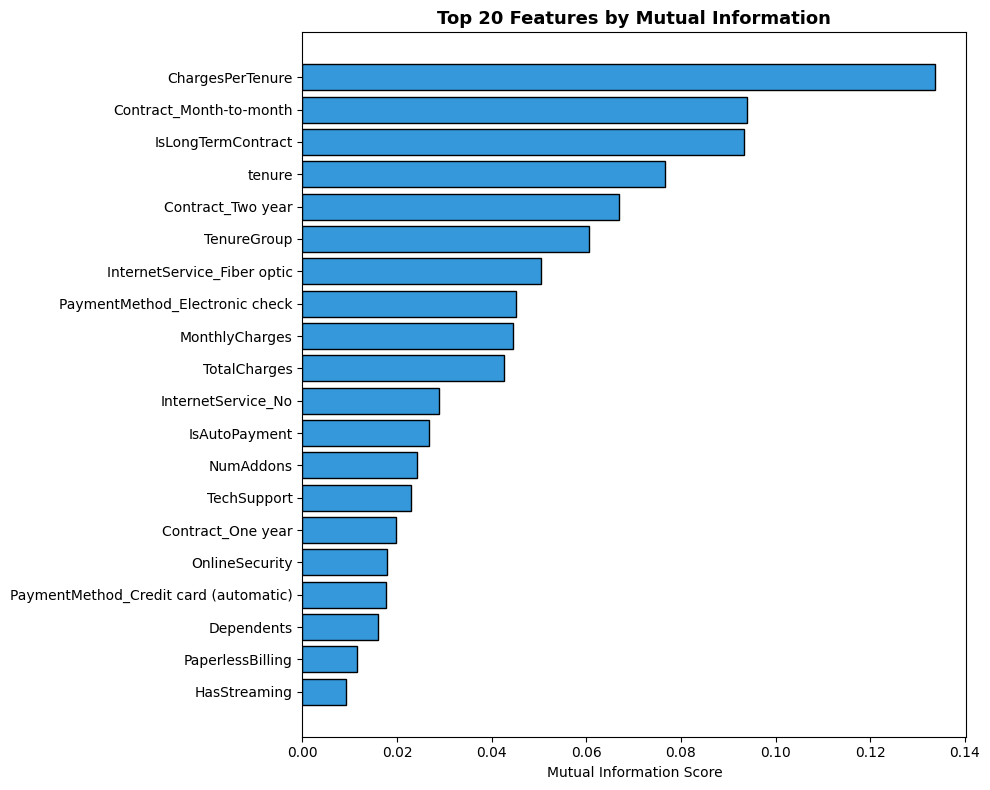


Top 20 Features:
                              Feature  MI_Score
                     ChargesPerTenure  0.133606
              Contract_Month-to-month  0.093910
                   IsLongTermContract  0.093243
                               tenure  0.076603
                    Contract_Two year  0.066944
                          TenureGroup  0.060585
          InternetService_Fiber optic  0.050356
       PaymentMethod_Electronic check  0.045190
                       MonthlyCharges  0.044562
                         TotalCharges  0.042554
                   InternetService_No  0.028816
                        IsAutoPayment  0.026708
                            NumAddons  0.024270
                          TechSupport  0.022935
                    Contract_One year  0.019767
                       OnlineSecurity  0.017782
PaymentMethod_Credit card (automatic)  0.017687
                           Dependents  0.015922
                     PaperlessBilling  0.011504
                      

In [88]:
from sklearn.feature_selection import mutual_info_classif

X = df_fe.drop(columns=['Churn'])
y = df_fe['Churn']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Plot top 20
plt.figure(figsize=(10, 8))
top20 = mi_df.head(20)
bars = plt.barh(top20['Feature'][::-1], top20['MI_Score'][::-1],
                color='#3498db', edgecolor='black')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/09_feature_importance_mi.png', dpi=150)
plt.show()

print("\nTop 20 Features:")
print(mi_df.head(20).to_string(index=False))

In [89]:
# Drop low-information features (MI < 0.005)
low_info = mi_df[mi_df['MI_Score'] < 0.005]['Feature'].tolist()
print("Dropping low-info features:", low_info)

df_final = df_fe.drop(columns=low_info)

# Also drop TotalCharges (high collinearity with tenure x MonthlyCharges)
if 'TotalCharges' in df_final.columns:
    df_final.drop(columns=['TotalCharges'], inplace=True)
    print("Dropped: TotalCharges (collinear)")

print("\nFinal feature set shape:", df_final.shape)
print("Features:", df_final.drop(columns=['Churn']).columns.tolist())

Dropping low-info features: ['SeniorCitizen', 'Partner', 'OnlineBackup', 'gender', 'PaymentMethod_Bank transfer (automatic)', 'StreamingMovies', 'DeviceProtection', 'PhoneService', 'PaymentMethod_Mailed check']
Dropped: TotalCharges (collinear)

Final feature set shape: (7032, 23)
Features: ['Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'PaperlessBilling', 'MonthlyCharges', 'ChargesPerTenure', 'TenureGroup', 'NumAddons', 'HasStreaming', 'IsLongTermContract', 'IsAutoPayment', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']


In [90]:
print("=== FINAL ENGINEERED DATASET ===")
print(f"Shape         : {df_final.shape}")
print(f"Nulls         : {df_final.isnull().sum().sum()}")
print(f"Target balance: {df_final['Churn'].value_counts().to_dict()}")
print(f"All dtypes int/float: {all(df_final.dtypes != 'object')}")
print(f"\nColumns:\n{df_final.columns.tolist()}")

=== FINAL ENGINEERED DATASET ===
Shape         : (7032, 23)
Nulls         : 0
Target balance: {0: 5163, 1: 1869}
All dtypes int/float: True

Columns:
['Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'ChargesPerTenure', 'TenureGroup', 'NumAddons', 'HasStreaming', 'IsLongTermContract', 'IsAutoPayment', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']


In [91]:
df_final.to_csv('../data/featured_churn.csv', index=False)
print("Saved → data/featured_churn.csv")

Saved → data/featured_churn.csv


In [92]:
# 1. Get raw counts
print("--- Raw Counts ---")
print(df_fe['Churn'].value_counts())

# 2. Get percentages (Imbalance Ratio)
print("\n--- Percentage Split ---")
print(df_fe['Churn'].value_counts(normalize=True) * 100)

--- Raw Counts ---
Churn
0    5163
1    1869
Name: count, dtype: int64

--- Percentage Split ---
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


In [93]:
counts = df_fe['Churn'].value_counts()
majority_class = counts.max()
minority_class = counts.min()

imbalance_ratio = majority_class / minority_class
print(f"Imbalance Ratio: {imbalance_ratio:.2f} : 1")

Imbalance Ratio: 2.76 : 1
